# 生成伪实验数据

包含：$I(t)$，$Q(t)$。其中每个样本取200个时间点，训练用50000个样本，测试用10000个样本。

### 1. 物理模型概述

我们使用一个 **两模线性模型** 来描述超导量子比特的色散读出结构：

- **模式 a**：Purcell 滤波器，负责将读出信号耦合到传输线，同时抑制量子比特的辐射损耗  
- **模式 b**：读出谐振腔，与量子比特色散耦合

两个模式通过耦合常数 $J$ 相互作用。量子比特本身 **不作为动力学自由度显式模拟**，而是在色散极限下，通过对读出腔频率的位移来体现其状态：

- 量子比特处于 $|g⟩$：  $ \omega_b \rightarrow \omega_b - \chi $
- 量子比特处于 $|e⟩$：  $ \omega_b \rightarrow \omega_b + \chi $

所有动力学都在驱动频率 $\omega_d$ 的旋转坐标系中进行，因此模拟的量是 **复包络（baseband）**，而不是 GHz 量级的真实 RF 信号。

定义：

- 失谐：$\Delta_a = \omega_a - \omega_d$，$\Delta_b = \omega_b - \omega_d$，$\Delta_{b,s} = \Delta_b + s\chi$，其中 $s=-1$ 表示 $|g⟩$，$s=+1$ 表示 $|e⟩$
- 耗散：外耦合速率 $\kappa_a,\ \kappa_b$，内损耗速率 $\gamma_a,\ \gamma_b$，总半线宽 $\Gamma_a = (\kappa_a + \gamma_a)/2,\ \Gamma_b = (\kappa_b + \gamma_b)/2$

在旋转系中，两模的平均场演化方程为：

\begin{aligned}
\frac{da}{dt} &= -(\Gamma_a + i\Delta_a)\,a - iJ b + \sqrt{\kappa_a}\,a_{\text{in}}(t) \\
\frac{db}{dt} &= -(\Gamma_b + i\Delta_{b,s})\,b - iJ a
\end{aligned}

在当前数据生成器中，假设驱动仅从 Purcell 滤波器侧注入，因此 $b_{\text{in}}(t)=0$。

### 2. 输入–输出关系

根据输入–输出理论，可得到端口处的输出场：

- **Purcell 端口（反射型读出）**：$ a_{\text{out}}(t) = a_{\text{in}}(t) - \sqrt{\kappa_a}\,a(t) $

- **读出腔端口**：$ b_{\text{out}}(t) = -\sqrt{\kappa_b}\,b(t) $

生成脚本中可以通过参数 `measure="a_out"（默认）` 或 `"b_out"` 来选择观测哪一路信号。

### 3. IQ 信号与 RF 信号的关系

本模型直接输出 **IQ 基带信号** $s(t)$，它等价于理想 IQ 解调后的结果：$ I(t) = \Re[s(t)], \ Q(t) = \Im[s(t)] $

如果要写出对应的真实 RF 电压信号，其形式为：$ V_{\text{RF}}(t) \propto \Re\left\{ s(t)\,e^{-i\omega_d t} \right\} $

### 4. 数字滤波

实验中通常不会直接用完整的时间序列做判决，而是对某个时间窗内的 IQ 信号做积分或加权：$z = \int w(t)\,[I(t) + iQ(t)]\,dt$

常见选择包括：**1. Boxcar 积分**：$ w(t)=\text{const} $，在读出脉冲平顶区间内平均。**2. 匹配滤波（matched filter）**：$ w(t) \propto \langle s_e(t) - s_g(t) \rangle $。

### 5. IQ 不平衡与振荡的来源

实验中常见的一个现象是 IQ 波形中叠加周期性振荡（例如 ~50 MHz），这通常来自 **IQ 不平衡或镜像频率泄露**。

在基带中，一个常用的模型是：$s_{\text{meas}}(t) = s(t) + \varepsilon\,e^{i2\omega_{\text{IF}}t}\,s^*(t)$

其中：IQ 不平衡强度 $\varepsilon$，产生拍频的角频率 $2\omega_{\text{IF}}$。生成器中通过 `iq_imbalance` 与 `beat_freq_MHz` 参数来控制该效应。

### 6. 噪声模型
为了更贴近真实实验，数据生成器包含三类常见噪声：
1. **放大器白噪声 `amp_noise_std`**：每个采样点独立加入，模拟 HEMT/JPA 等放大链路噪声
2. **相位噪声 `phase_noise_std`**：每条读出波形整体乘以随机相位 $e^{i\phi}$，对应本振（LO）相位抖动、触发抖动等
3. **慢频漂 `slow_detune_std`**：每个 shot 的共振频率随机漂移，用于模拟低频噪声、1/f 噪声或实验环境漂移

### 7. 数据集格式（`.npz`）

生成的数据集面向机器学习与数值分析，**不包含显式时间轴**。
保存内容包括：
- `X_train`：形状 `(n_train, n_points, 2)`，`float32`；最后一维为 `[I, Q]`
- `y_train`：形状 `(n_train,)`，`int64`；标签：`0 = |g⟩`，`1 = |e⟩`
- `X_test`, `y_test`：与训练集格式相同
- `params_json`：JSON 字符串，记录生成该数据集时使用的所有参数


In [136]:
!python -m scripts.gen_data_readout --out data/test_readout.npz --n_points 200 --n_train 20000 --n_test 2000 --amp_noise_std 0.1 --phase_noise_std 0.05

Saved data/test_readout.npz
train: (20000, 200, 2) test: (2000, 200, 2)


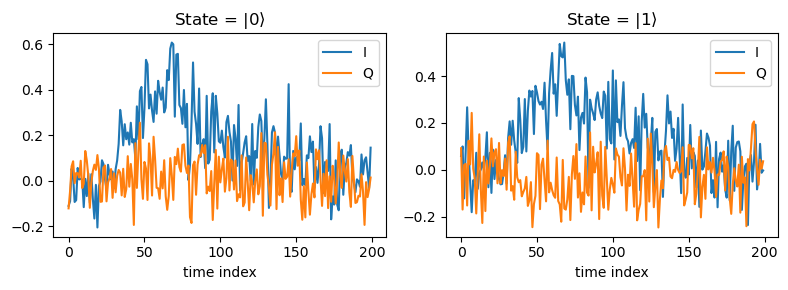

In [137]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/test_readout.npz", allow_pickle=True)
Xtr, y_train, Xte, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]
X_train = np.mean(Xtr, axis=1)
X_test = np.mean(Xte, axis=1)

rng = np.random.default_rng()
idx0 = rng.choice(np.where(y_train == 0)[0])
idx1 = rng.choice(np.where(y_train == 1)[0])

x0, x1 = Xtr[idx0,:,:], Xtr[idx1,:,:]

titles = [fr"State = $|0\rangle$", fr"State = $|1\rangle$"]

t = np.arange(x0.shape[0])

plt.figure(figsize=(8,3))

for (i, x) in zip([0,1], [x0,x1]):
    plt.subplot(1,2,i+1)
    plt.plot(t, x[:,0], label='I')
    plt.plot(t, x[:,1], label='Q')
    plt.title(titles[i])
    plt.xlabel('time index')
    plt.legend()

plt.tight_layout()
plt.show()

# 简单分类

对 IQ 信号进行简单平均，$I=\langle I(t)\rangle$, $Q=\langle Q(t)\rangle$，再用逻辑回归或支持向量机直接进行分类。

In [ ]:
import numpy as np
import torch
from src.common import make_loader
from src.readout import train_simple, eval_nn
from src.readout import LDA, MatchedFilter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 10

d = np.load("data/test_readout.npz", allow_pickle=True)
X_train, y_train, X_test, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]

# Prepare loaders for ML
train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
test_loader  = make_loader(X_test, y_test, batch_size=2048, shuffle=False)
T = X_train.shape[1]

lda = train_simple(LDA(T), train_loader, device, epochs=epochs)
acc_lda, nll_lda = eval_nn(lda, test_loader, device)

mf = train_simple(MatchedFilter(T), train_loader, device, epochs=epochs)
acc_mf, nll_mf = eval_nn(mf, test_loader, device)



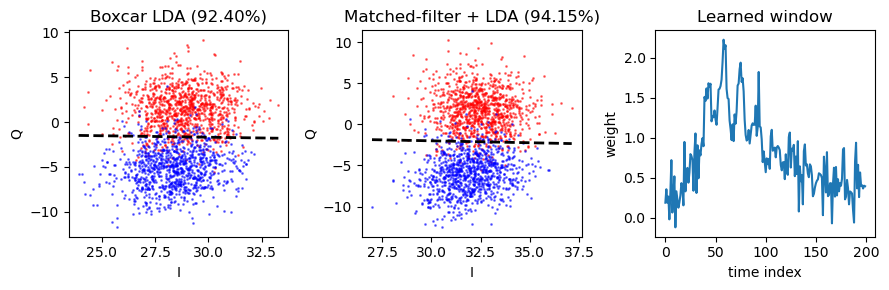

In [ ]:
import matplotlib.pyplot as plt

I = X_test[:,:,0].sum(axis=1)
Q = X_test[:,:,1].sum(axis=1)

w = (lda.fc.weight[1] - lda.fc.weight[0]).detach().cpu().numpy()
c = (lda.fc.bias[1]   - lda.fc.bias[0]).detach().cpu().item()

plt.figure(figsize=(9,3))
# ---------- (1) boxcar IQ + LDA 直线 ----------
plt.subplot(1,3,1)
plt.scatter(I[y_test==0], Q[y_test==0], s=1, alpha=0.5, c='r')
plt.scatter(I[y_test==1], Q[y_test==1], s=1, alpha=0.5, c='b')

I_line = np.linspace(np.min(I), np.max(I), 200)
if abs(w[1]) < 1e-12:
    plt.axvline(-c/(w[0]+1e-12), linestyle="--")
else:
    Q_line = -(w[0]*I_line + c)/w[1]
    plt.plot(I_line, Q_line, "k--", linewidth=2)

plt.title(f"Boxcar LDA ({acc_lda*100:{".2f"}}%)")
plt.xlabel("I"); plt.ylabel("Q"); 

w_t = mf.window.detach().cpu().numpy().flatten()
I2 = (X_test[:,:,0]*w_t).sum(axis=1)
Q2 = (X_test[:,:,1]*w_t).sum(axis=1)

w2 = (mf.fc.weight[1] - mf.fc.weight[0]).detach().cpu().numpy()
c2 = (mf.fc.bias[1]   - mf.fc.bias[0]  ).detach().cpu().item()

# ---------- (2) matched-filter IQ + MF 直线 ----------
plt.subplot(1,3,2)
plt.scatter(I2[y_test==0], Q2[y_test==0], s=1, alpha=0.5, c='r')
plt.scatter(I2[y_test==1], Q2[y_test==1], s=1, alpha=0.5, c='b')

I_line2 = np.linspace(np.min(I2), np.max(I2), 200)
if abs(w2[1]) < 1e-12:
    plt.axvline(-c2/(w2[0]+1e-12), linestyle="--")
else:
    Q_line2 = -(w2[0]*I_line2 + c2)/w2[1]
    plt.plot(I_line2, Q_line2, "k--", linewidth=2)

plt.title(f"Matched-filter + LDA ({100*acc_mf:{".2f"}}%)")
plt.xlabel("I"); plt.ylabel("Q"); 

# ---------- (3) matched filter window ----------
plt.subplot(1,3,3)
plt.plot(w_t)
plt.title("Learned window")
plt.xlabel("time index"); plt.ylabel("weight")
plt.tight_layout()
plt.show()

# 用各种机器学习模型分类

优势在于充分利用了 $I(t)$，$Q(t)$ 中的时间信息。

1. 训练时间窗，通过数字滤波（Matched filter）得到 IQ 点
2. 训练两个状态对应的模板，用贝叶斯推断
3. 训练神经网络

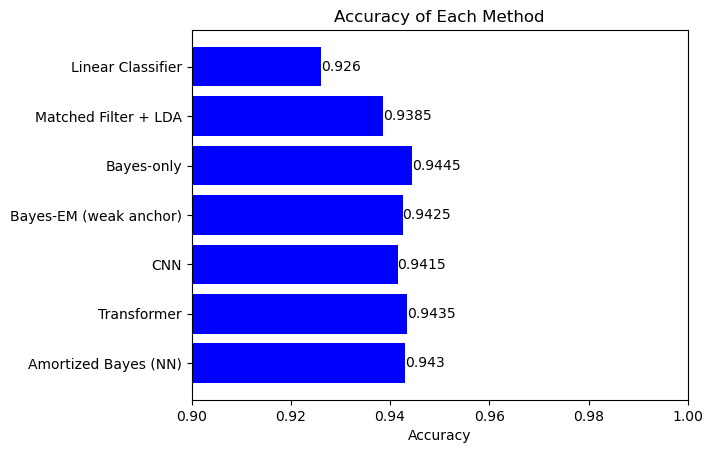

,acc,nll,time,sigma
Linear Classifier,0.9260,0.181874,7.685326,NaN
Matched Filter + LDA,0.9385,0.152850,4.683996,NaN
Bayes-only,0.9445,0.303039,NaN,NaN
Bayes-EM (weak anchor),0.9425,0.309956,NaN,0.100266
CNN,0.9415,0.147108,9.934107,NaN
Transformer,0.9435,0.140321,251.471612,NaN
Amortized Bayes (NN),0.9430,0.144451,24.678516,NaN


In [31]:
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd 

# Run the script and capture output
result = subprocess.run(
    ['python', '-m', 'scripts.run_readout_all', '--in_npz', 'data/test_readout.npz', 
     '--em_iter', '100', '--hmm_iter', '100', '--epochs=100'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)

if result.stderr == '':
    # Capture the results dictionary from the stdout (if printed by the script)
    json_output = result.stdout.split("All Results:")[-1].strip().replace("'", '"')
    results = json.loads(json_output)

    # Extract accuracies for plotting
    methods =list(results.keys())
    accuracies = [results[method]["acc"] for method in methods]
    nlls = [results[method]["nll"] for method in methods]

    # Plot the accuracies as a bar chart
    fig, ax = plt.subplots()
    bars = plt.barh(methods[::-1], accuracies[::-1], color="b")
    ax.bar_label(bars)
    ax.set_xlim((0.9, 1.0))
    ax.set_xlabel('Accuracy')
    ax.set_title('Accuracy of Each Method')
    # plt.grid(True, axis='x')
    plt.show()
    
    display( pd.DataFrame(results).transpose() )
else:
    print( result.stderr )
